In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as con
from scipy.special import erf, erfi
from numpy import sqrt, pi, exp
import scipy

# 23/03/2025

In [2]:
def speed(v):
    return sqrt(np.sum(v**2))

def Nesc_gaussian(sig, v_esc):
    # Got this from github.com/cajohare/DarkShards/blob/master/code/HaloFuncs.py
    # sig = 1d dispersion
    # v_esc = escape velocity
    return erf(v_esc/(sqrt(2)*sig)) - \
    sqrt(2.0/pi)*(v_esc/sig)*exp(-v_esc**2.0/(2.0*sig**2.0))

def fv_gaussian(v, sig, v_c, v_esc = 528.0):
    constants = 2 * pi * sig**2
    constants = 1 / (np.pow(constants, 3/2))
    
    N_esc = Nesc_gaussian(sig, v_esc)
    
    f = exp(-(speed(v - v_c)**2) / 2 / (sig**2)) / N_esc
    
    return constants * f

def speedDistGaussian(v, sig, v_c, v_esc= 528.0):
    constants = v / (sqrt(2*pi) * v_c * sig)
    
    # got this from ciaran's fine grained dark matter paper, is v_e supposed to be v_c?
    f1 = exp(- (v**2 + v_c**2 - 2*v*v_c) / (2 * sig**2))
    f2 = exp(- (v**2 + v_c**2 + 2*v*v_c) / (2 * sig**2))
    
    N_esc = Nesc_gaussian(sig, v_esc) # what is N_esc?
    #print(N_esc)
    
    return (f1 - f2) * constants / N_esc
    

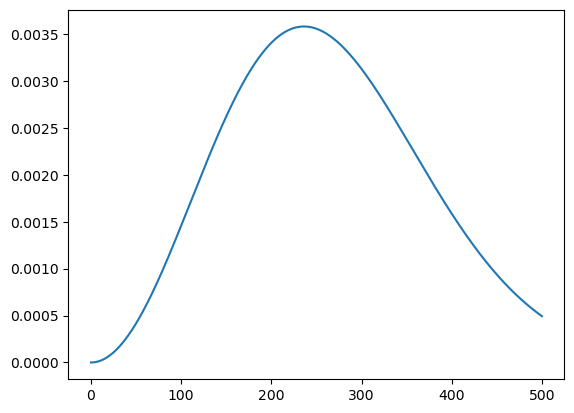

In [123]:
# example of single gaussian/stream

plt.clf()
v = np.linspace(0, 500, 10000)
sig = 167
f = speedDistGaussian(v, sig, 1)
plt.plot(v, f)

In [4]:
def streamN(v):
    sigg = 2.58
    sige = 5.6
    c_0 = 1.1
    f1 = exp(-0.5 * v**2 / sigg**2)
    f2 = c_0 * exp(- np.abs(v) / sige)
    return f1+f2

<Figure size 640x480 with 0 Axes>

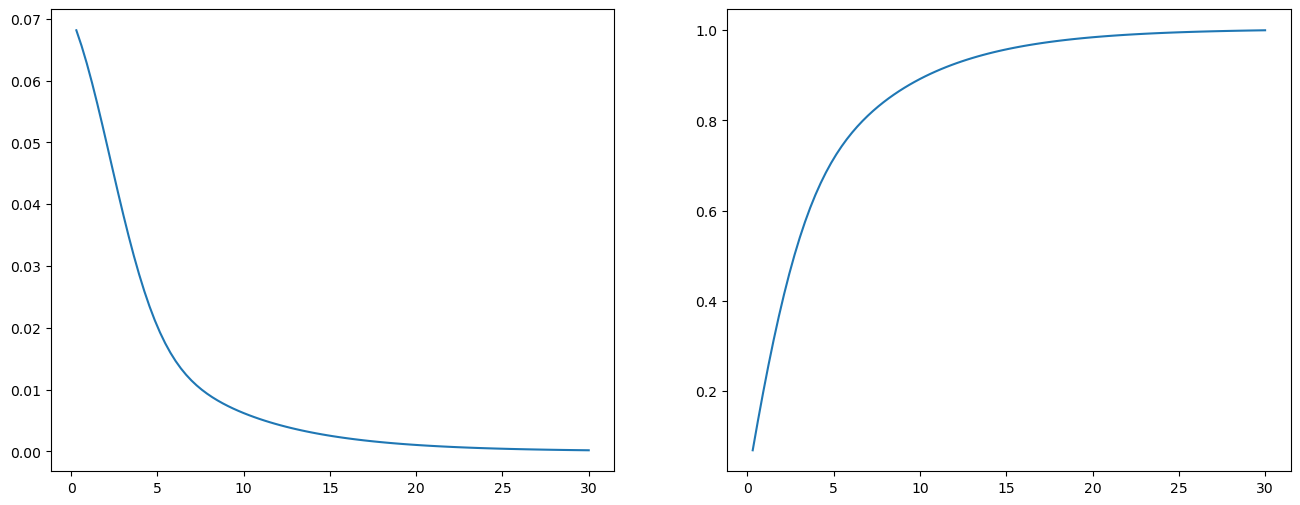

In [22]:
#from https://iopscience.iop.org/article/10.3847/1538-4357/ad7b35
#using random constant values for now
# this is just a placeholder to find a value for N_str, i didn't read thru the full paper
# the paper produces the plots below based on radial velocity?

v = np.linspace(0, 30, 100)[1:] # the paper goes from -20 to 20, \
    #however we don't care the direction only the speed of the stream
    # maybe need to change the maximum velocity??
y = streamN(v) / np.sum(streamN(v))
plt.clf()
fig, ax = plt.subplots(1, 2, figsize=(16,6))
ax[0].plot(v, y)
ax[1].plot(v, y.cumsum())

v_str = np.column_stack((v, y))
#np.random.seed(0)
#v_str = np.random.choice(a=v, p=y, size = 1000)



In [ ]:
np.random.seed(0)
v_strs = np.random.choice(a=v, p=y, size = 10000)
y = streamN(v_strs)
y = y / np.sum(y)
v_str = np.column_stack((v_strs, y))

In [25]:
v = np.linspace(0, 30, 1000)[1:]

f = []
sig = 0.005
for i in v_str:
    v_c = i[0]
    p = i[1]
    f.append(p* speedDistGaussian(v, sig, v_c))

f = np.array(f)

<Figure size 640x480 with 0 Axes>

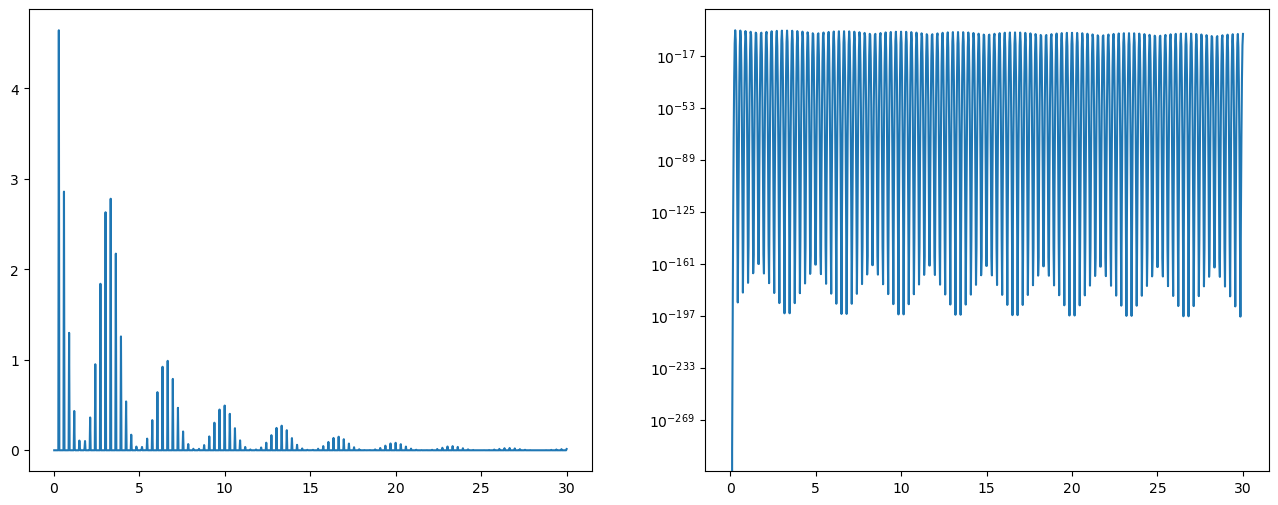

In [26]:
plt.clf()
plt.clf()
fig, ax = plt.subplots(1, 2, figsize=(16,6))
ax[0].plot(v, f.sum(axis=0))
ax[1].semilogy(v, f.sum(axis=0))

In [47]:
v_str[:, 0]

array([3.12663127, 4.99414994, 3.61773618, ..., 5.74715747, 0.10680107,
       7.03447034], shape=(10000,))

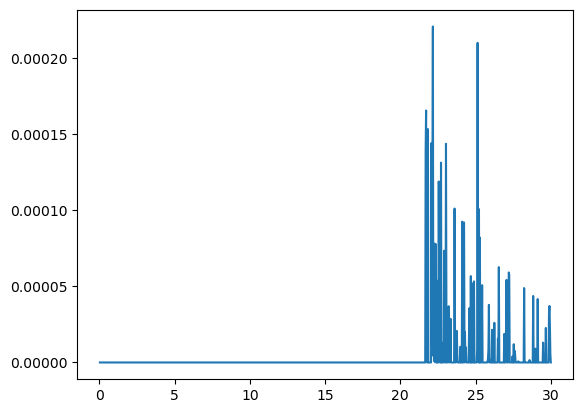

In [79]:
plt.clf()
plt.plot(v, f[np.argsort(v_str[:, 0])][::-1][:100].sum(axis=0))

In [57]:
np.argsort(v_str[:, 0])[::-1]

array([8163, 2749, 5081, ..., 7648, 3856, 2055], shape=(10000,))

In [69]:
f[np.argsort(v_str[:, 0])][::-1][:50].sum(axis=0)

array([0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0

In [ ]:
# random.multivariate_normal, centred on (0, 0, 0), covariance is diagonal (dispersion of halo squared ~167)
# look at fine gained structured for rho/M
# velocity of streams 
# phase mixing

# for traferring to signal use A.2 in fine grained
# quality factor q = w_0 / delta w = m_a / m_a / v^2

# 25th to 31st March
## Feedback:
- Better to sample stream velocities from the halo's gaussian distribution. Easy to do this, just use random.multivariate_normal, centred on (0, 0, 0), covariance is diagonal (dispersion of halo squared ~167)
- Each stream should have a different density as well. Specifically we use, f (ρ) = scipy.stats.skewnorm.pdf(log(rho),-2.10,loc=-11.37,scale=7.15)/rho, as shown in Ciaran's Fine-grained dark matter paper
- Look at phase mixing, it tells us about velocity of streams/ how the streams came to be (folds etc.) (optional for now)
- After making a proper model/distribution, look into extracting/transforming it into a signal (A.2. in fine grained.) quality factor q = w_0 / delta w = m_a / m_a / v^2


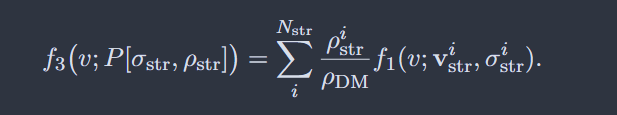

In [2]:
def speed(v):
    return sqrt(np.sum(v**2, axis = 1))

def Nesc_gaussian(sig, v_esc):
    # Got this from github.com/cajohare/DarkShards/blob/master/code/HaloFuncs.py
    # sig = 1d dispersion
    # v_esc = escape velocity
    return erf(v_esc/(sqrt(2)*sig)) - \
    sqrt(2.0/pi)*(v_esc/sig)*exp(-v_esc**2.0/(2.0*sig**2.0))

def fv_gaussian(v, sig, v_c, v_esc = 528.0):
    constants = 2 * pi * sig**2
    constants = 1 / (np.pow(constants, 3/2))
    
    N_esc = Nesc_gaussian(sig, v_esc)
    
    f = exp(-(speed(v - v_c)**2) / 2 / (sig**2)) / N_esc
    
    return constants * f

def speedDistGaussian(v, sig, v_c, v_esc= 528.0):
    constants = v / (sqrt(2*pi) * v_c * sig)
    
    # got this from ciaran's fine grained dark matter paper, is v_e supposed to be v_c?
    f1 = exp(- (v**2 + v_c**2 - 2*v*v_c) / (2 * sig**2))
    f2 = exp(- (v**2 + v_c**2 + 2*v*v_c) / (2 * sig**2))
    
    N_esc = Nesc_gaussian(sig, v_esc) # what is N_esc?
    #print(N_esc)
    
    return (f1 - f2) * constants / N_esc

In [3]:
def fun(rho, str_num):
    return np.abs(scipy.stats.skewnorm.pdf(np.log(rho),-2.10,loc=-11.37,scale=7.15)/rho - str_num)

def get_density(str_num):
    # returns the optimum stream density to get 
    return scipy.optimize.minimize(fun, x0 = 2.04e-3, bounds = [(7.7e-8, np.inf)], args=[str_num]).x[0]

v_c = 1 # just set it to 1 cause v_c = 0 breaks the function

num = 1000
np.random.seed(0)
vel = np.random.multivariate_normal((0, 0, 0), np.diag([167]*3), num)
spd = speed(vel) + v_c

rho = []
for str_num in range(1, num+1):
    rho.append(get_density(str_num))

streams = np.column_stack([spd, rho])


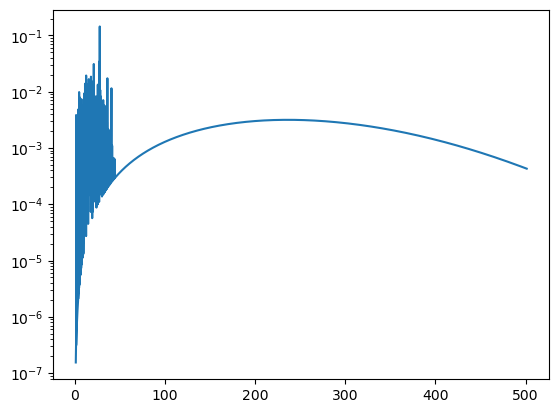

In [4]:
plt.clf()
deltas = []
sig = 0.01 # ask ciaran what do to about the dispersion velocities
v = np.logspace(0, 2.7, 1000)
for v_e, p in streams:
    gauss = p * speedDistGaussian(v, sig, v_e)
    deltas.append(gauss)

perturb = np.sum(deltas, axis = 0)
total = speedDistGaussian(v, 167, v_c) * (1 - np.sum(rho)) + perturb

plt.semilogy(v, total)

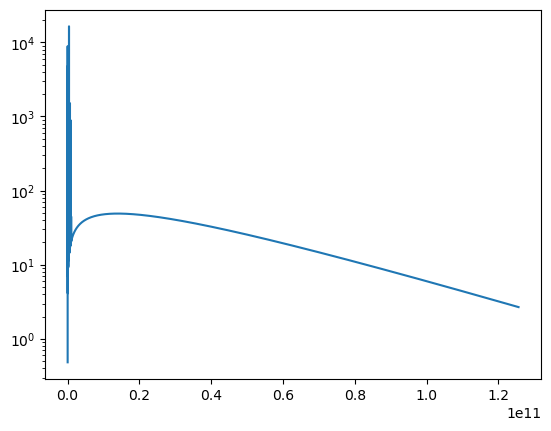

In [5]:
m_a = 1e-6 # in eV
lineshape = np.pi * total / (m_a *v) # T -> infty

w = (v*v + 2)*m_a / 2
plt.clf()
plt.semilogy((w/m_a - 1) * 1e6, lineshape)

In [183]:
# CONVERT IT FOR LOCAL SUN

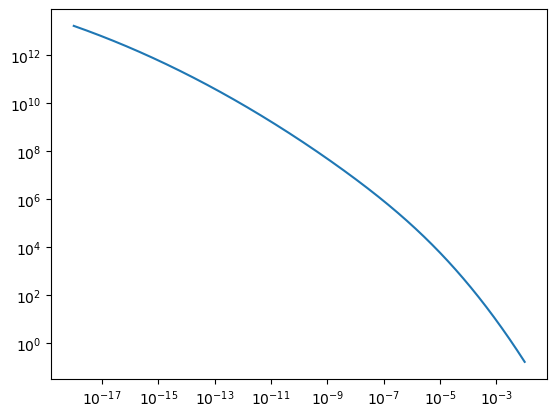

In [73]:
rho = np.logspace(-18, -2, 1000)
f = scipy.stats.skewnorm.pdf(np.log(rho),-2.10,loc=-11.37,scale=7.15)/rho
plt.clf()
plt.loglog(rho, f)

In [77]:
streams.shape

(100, 4)

In [68]:
rho = get_density(100)
scipy.stats.skewnorm.pdf(np.log(rho),-2.10,loc=-11.37,scale=7.15)/rho, rho

(np.float64(100.00114332511777), np.float64(0.00020486953897739518))